# **IISc-Arm Instruction Enhancement Program (IEP) on Edge AI**
## website: https://cds.iisc.ac.in/faculty/simmhan/conf/arm-iep-2026/

# Author: Dr. Pandarasamy Arjunan and Students
## Center for Cyber Physical Systems, Indian Institute of Science.
## Contact: samy@iisc.ac.in


### References
 1. TinyML and Efficient Deep Learning Computing https://hanlab.mit.edu/courses/2024-fall-65940
 2. Various internet sources


# Lab 2: Model Parameters and Efficiency Metrics of CNNs



In this tutorial, you will learn how to build a Convolutional Neural Network (CNN) and evaluate it using both performance and efficiency metrics. The goal is not only to train a model that predicts correctly, but also to understand how complex, computationally expensive, and memory-intensive the model is.

Most beginners focus only on accuracy, but real-world machine learning requires evaluating models from multiple perspectives, including parameter count, memory usage, activations, and computational cost. This tutorial will help you understand how these aspects influence model performance and deployment feasibility.

You will work with the MNIST handwritten digits dataset and implement a CNN model step by step. Along the way, you will analyze training behavior, interpret results, and explore efficiency metrics such as FLOPs and model size.


1. Train and test a CNN for image classification  
2. Understand parameters/weights of different CNN layers  
   - 1D Convolution  
   - 2D Convolution  
   - Grouped Convolution  
   - Depthwise Convolution  
3. Understand efficiency metrics  
   - Compute metrics (FLOPs, MACs)  
   - Memory metrics (parameters, model size, activations)


# Convolution

Convolution is a fundamental operation in neural networks that helps models automatically learn patterns from data. Instead of manually designing features, convolution allows the model to scan the input using small filters and detect meaningful structures such as edges, shapes, trends, and textures. Depending on the type of data and computational requirements, different forms of convolution are used, namely 1D convolution, 2D convolution, grouped convolution, and depth-wise convolution. Each of these serves a specific purpose in deep learning and computer vision.


### 1D Convolution
1D convolution is used when the data is sequential or varies over time. It operates along a single dimension and is commonly applied to time-series data, audio signals, sensor readings, and text. In this type of convolution, a small filter moves across the sequence and performs weighted calculations to detect patterns such as trends, peaks, or repeating signals. For example, in ECG data, a 1D convolution can help identify heart rhythm patterns. The main objective of 1D convolution is to capture relationships across time or sequence order rather than spatial structure.


![1d_conv.png](https://drive.usercontent.google.com/download?id=1nfhEgJvvpeg5-JLrhNX69ueeSXR4KDkE&export=download&authuser=0)
Image source:  https://hanlab.mit.edu/courses/2024-fall-65940

Let:

- Input sequence: $ x $
- Kernel/filter: $ w $
- Output: $ y $
- Kernel size: $ k $

Then the convolution output at position $ t $ is:

$$
y(t) = \sum_{i=0}^{k-1} w(i) \cdot x(t + i)
$$

If bias is included:

$$
y(t) = \sum_{i=0}^{k-1} w(i) \cdot x(t + i) + b
$$

**Output Length**

$$
\text{Output Length} = \frac{N - K + 2P}{S} + 1
$$

Where:
- $ N $ = input length
- $ K $ = kernel size
- $ P $ = padding
- $ S $ = stride


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

window_size = 20         # time window / sliding window size (number of timesteps per segment)
num_input_channels = 6   # raw IMU channels: ax, ay, az, gx, gy, gz
num_activities = 3       # number of activity classes to predict

model = models.Sequential([
    layers.Input(shape=(window_size, num_input_channels)),
    layers.Conv1D(filters=8, kernel_size=3, strides=1, padding="valid", activation="relu"),
    layers.Flatten(),
    layers.Dense(num_activities, activation="softmax")
])

model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 18, 8)          │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 587 (2.29 KB)

 Trainable params: 587 (2.29 KB)

 Non-trainable params: 0 (0.00 B)


# Layer-wise Parameter Analysis (1D CNN for HAR)

## Notations

* $c_i$ : Input channels
* $c_o$ : Output channels (number of filters)
* $w_i, w_o$ : Input/output width (time window size)
* $k_w$ : Kernel width

---

## Given Model

* $w_i = 20$
* $c_i = 6$
* Conv1D: $c_o = 8$, $k_w = 3$, stride $s = 1$, padding = valid
* Dense output units = $3$

---

## 1. Input Layer

Shape per sample: $ (w_i, c_i) = (20, 6) $

Trainable parameters: $0$

---

## 2. Conv1D Layer

### Output Width

$$
w_o = \left\lfloor \frac{w_i - k_w}{s} \right\rfloor + 1
$$

Substituting values:

$$
w_o = \frac{20 - 3}{1} + 1 = 18
$$

Output shape:

$$
(w_o, c_o) = (18, 8)
$$

### Parameters

Weights:

$$
k_w \cdot c_i \cdot c_o
$$

Bias:

$$
c_o
$$

Total Conv1D parameters:

$$
(k_w \cdot c_i \cdot c_o) + c_o
$$

$$
= (3 \cdot 6 \cdot 8) + 8
$$

$$
= 144 + 8 = 152
$$

---

## 3. Flatten Layer

Flatten output size:

$$
w_o \cdot c_o = 18 \cdot 8 = 144
$$

Trainable parameters:

$$
0
$$

---

## 4. Dense Layer (3 Activities)

Dense input units:

$$
w_o \cdot c_o = 144
$$

Total Dense parameters:

$$
(w_o \cdot c_o)\cdot 3 + 3
$$

$$
= 144 \cdot 3 + 3
$$

$$
= 432 + 3 = 435
$$

---

#  Total Trainable Parameters

$$
152 + 435 = 587
$$

---

### 2D Convolution

2D convolution is the most commonly used convolution in deep learning, especially in image processing. It operates across two dimensions, height and width, and is designed to extract spatial features from images. A filter slides over an image and detects visual patterns like edges, textures, corners, and shapes. In early layers of a neural network, 2D convolution typically learns basic features such as lines and edges, while deeper layers begin to recognize complex structures like faces or objects. This hierarchical feature learning is what makes convolutional neural networks highly effective for tasks such as image classification, object detection, and medical image analysis.


![2d_conv.png](https://drive.usercontent.google.com/download?id=1earZMuzWU0kXbeYuUKyG7USu8FFbXwTh&export=download&authuser=0)
Image source:  https://hanlab.mit.edu/courses/2024-fall-65940



Let:

- Input image: $ X $
- Kernel/filter: $ W $
- Output feature map: $ Y $

Then the output at position $ (i, j) $:

$$
Y(i,j) = \sum_{m=0}^{K_h-1} \sum_{n=0}^{K_w-1} W(m,n) \cdot X(i+m, j+n)
$$

With bias:

$$
Y(i,j) = \sum_{m=0}^{K_h-1} \sum_{n=0}^{K_w-1} W(m,n) \cdot X(i+m, j+n) + b
$$

**Output Size**

$$
\text{Output Height} = \frac{H - K_h + 2P}{S} + 1
$$

$$
\text{Output Width} = \frac{W - K_w + 2P}{S} + 1
$$


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),  # MNIST grayscale images
    layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding="valid", activation="relu"),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │       216,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,650 (846.29 KB)

 Trainable params: 216,650 (846.29 KB)

 Non-trainable params: 0 (0.00 B)

# Layer-wise Parameter Analysis of Conv2D Layer

## Notations (2D CNN)

* $n$ : Batch size
* $c_i$ : Input channels
* $c_o$ : Output channels (filters)
* $h_i, w_i$ : Input height & width
* $h_o, w_o$ : Output height & width
* $k_h, k_w$ : Kernel height & width

---

## Given

* MNIST image size: $28 \times 28$
* Grayscale → $c_i = 1$
* $c_o = 32$
* $k_h = k_w = 3$
* Stride $s = 1$
* Padding = valid

---

# 1. Input Layer

$$
(h_i, w_i, c_i) = (28, 28, 1)
$$

Trainable parameters:

$$
0
$$

---

# 2. Conv2D Layer

## Output Dimensions (valid padding, stride 1)

$$
h_o = \left\lfloor \frac{h_i - k_h}{s} \right\rfloor + 1
$$

$$
h_o = \frac{28 - 3}{1} + 1 = 26
$$

Similarly,

$$
w_o = 26
$$

Output shape:

$$
(h_o, w_o, c_o) = (26, 26, 32)
$$

---

## Conv2D Parameters

Weights:

$$
k_h \cdot k_w \cdot c_i \cdot c_o
$$

Bias:

$$
c_o
$$

Total parameters:

$$
(k_h \cdot k_w \cdot c_i \cdot c_o) + c_o
$$

Substitute values:

$$
(3 \cdot 3 \cdot 1 \cdot 32) + 32
$$

$$
= 288 + 32
$$

$$
= 320
$$

**Conv2D parameters = 320**

---

# 3. Flatten Layer

Flatten size:

$$
h_o \cdot w_o \cdot c_o
$$

$$
= 26 \cdot 26 \cdot 32
$$

$$
= 21,632
$$

Trainable parameters:

$$
0
$$

---

# 4. Dense Layer (10 classes)

Weights:

$$
21,632 \cdot 10
$$

Bias:

$$
10
$$

Total Dense parameters:

$$
(21,632 \cdot 10) + 10
$$

$$
= 216,320 + 10
$$

$$
= 216,330
$$

---

# Total Trainable Parameters

$$
320 + 216,330 = 216,650
$$


### Grouped Convolution

Grouped convolution is an extension of standard convolution designed to reduce computational cost while maintaining performance. In a typical convolution, filters operate across all input channels simultaneously, which can be computationally expensive. Grouped convolution divides input channels into separate groups and applies convolution independently to each group. This means the network learns features in parallel across smaller channel subsets. By doing so, it reduces the number of parameters and computation while still capturing useful patterns. This technique is used in architectures like ResNeXt to improve efficiency without sacrificing accuracy.


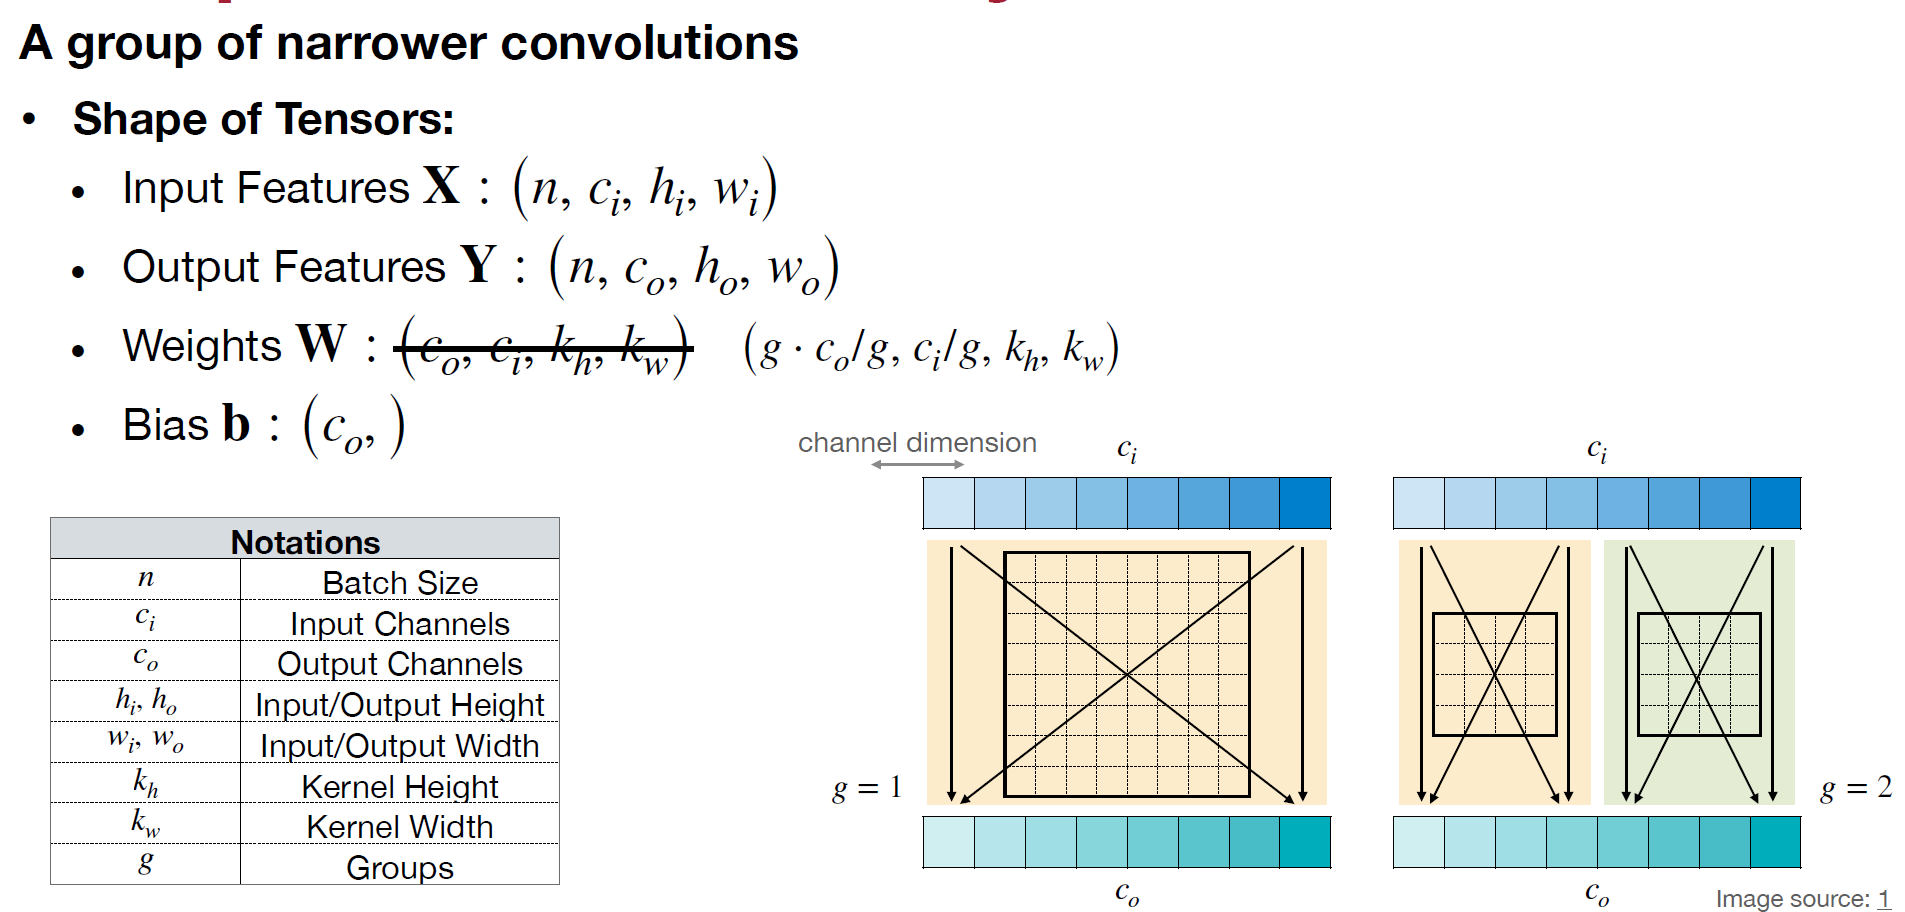

Image source:  https://hanlab.mit.edu/courses/2024-fall-65940

Let:
- Total input channels = $ C $
- Number of groups = $ G $
- Channels per group = $ C/G $

Each group performs convolution independently.

For group $ g $:

$$
Y_g = W_g * X_g
$$

Where:
- $ X_g $ = subset of input channels
- $ W_g $ = filters assigned to that group

Final output:

$$
Y = \text{Concat}(Y_1, Y_2, \dots, Y_G)
$$

**Parameter Count**

Standard convolution parameters:

$$
K_h \times K_w \times C \times F
$$

Grouped convolution parameters:

$$
K_h \times K_w \times \frac{C}{G} \times F
$$

This reduces computation and memory.



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

window_size = 20
num_input_channels = 6
num_activities = 3

model_grouped = models.Sequential([
    layers.Input(shape=(window_size, num_input_channels)),

    # Grouped Conv1D
    layers.Conv1D(filters=8,
                  kernel_size=3,
                  strides=1,
                  padding="valid",
                  activation="relu",
                  groups=2),   # splitting channels into 2 groups

    layers.Flatten(),
    layers.Dense(num_activities, activation="softmax")
])

model_grouped.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 8)          │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

# Grouped Convolution — Parameter Calculation

## Given

- Input width: $ w_i = 20 $
- Input channels: $ c_i = 6 $
- Output channels: $ c_o = 8 $
- Groups: $ G = 2 $
- Kernel size: $ k_w = 3 $
- Stride: $ s = 1 $
- Dense output units = 3

---

## Output Width

$$
w_o = \left\lfloor \frac{w_i - k_w}{s} \right\rfloor + 1
$$

$$
w_o = \frac{20 - 3}{1} + 1 = 18
$$

Output shape:

$$
(18, 8)
$$

---

## Grouped Conv Parameters

Channels per group:

$$
\frac{c_i}{G} = \frac{6}{2} = 3
$$

Weights per group:

$$
k_w \cdot \frac{c_i}{G} \cdot \frac{c_o}{G}
$$

$$
= 3 \cdot 3 \cdot 4 = 36
$$

Total weights across groups:

$$
36 \cdot 2 = 72
$$

Bias:

$$
c_o = 8
$$

Total Conv parameters:

$$
72 + 8 = 80
$$

---

## Flatten

$$
w_o \cdot c_o = 18 \cdot 8 = 144
$$

Parameters:

$$
0
$$

---

## Dense Layer

$$
144 \cdot 3 + 3 = 432 + 3 = 435
$$

---

## Total Parameters (Grouped Conv)

$$
80 + 435 = 515
$$







### Depth-wise Convolution

Depth-wise convolution is a specialized and more efficient form of convolution where each input channel is processed separately using its own filter. Unlike standard convolution, which combines information across all channels, depth-wise convolution focuses on extracting spatial features independently from each channel. This drastically reduces the number of parameters and computations required. It is widely used in lightweight neural network architectures such as MobileNet, which are designed for mobile devices, embedded systems, and real-time applications. Depth-wise convolution makes it possible to build deep learning models that are fast, memory-efficient, and suitable for deployment in resource-constrained environments.

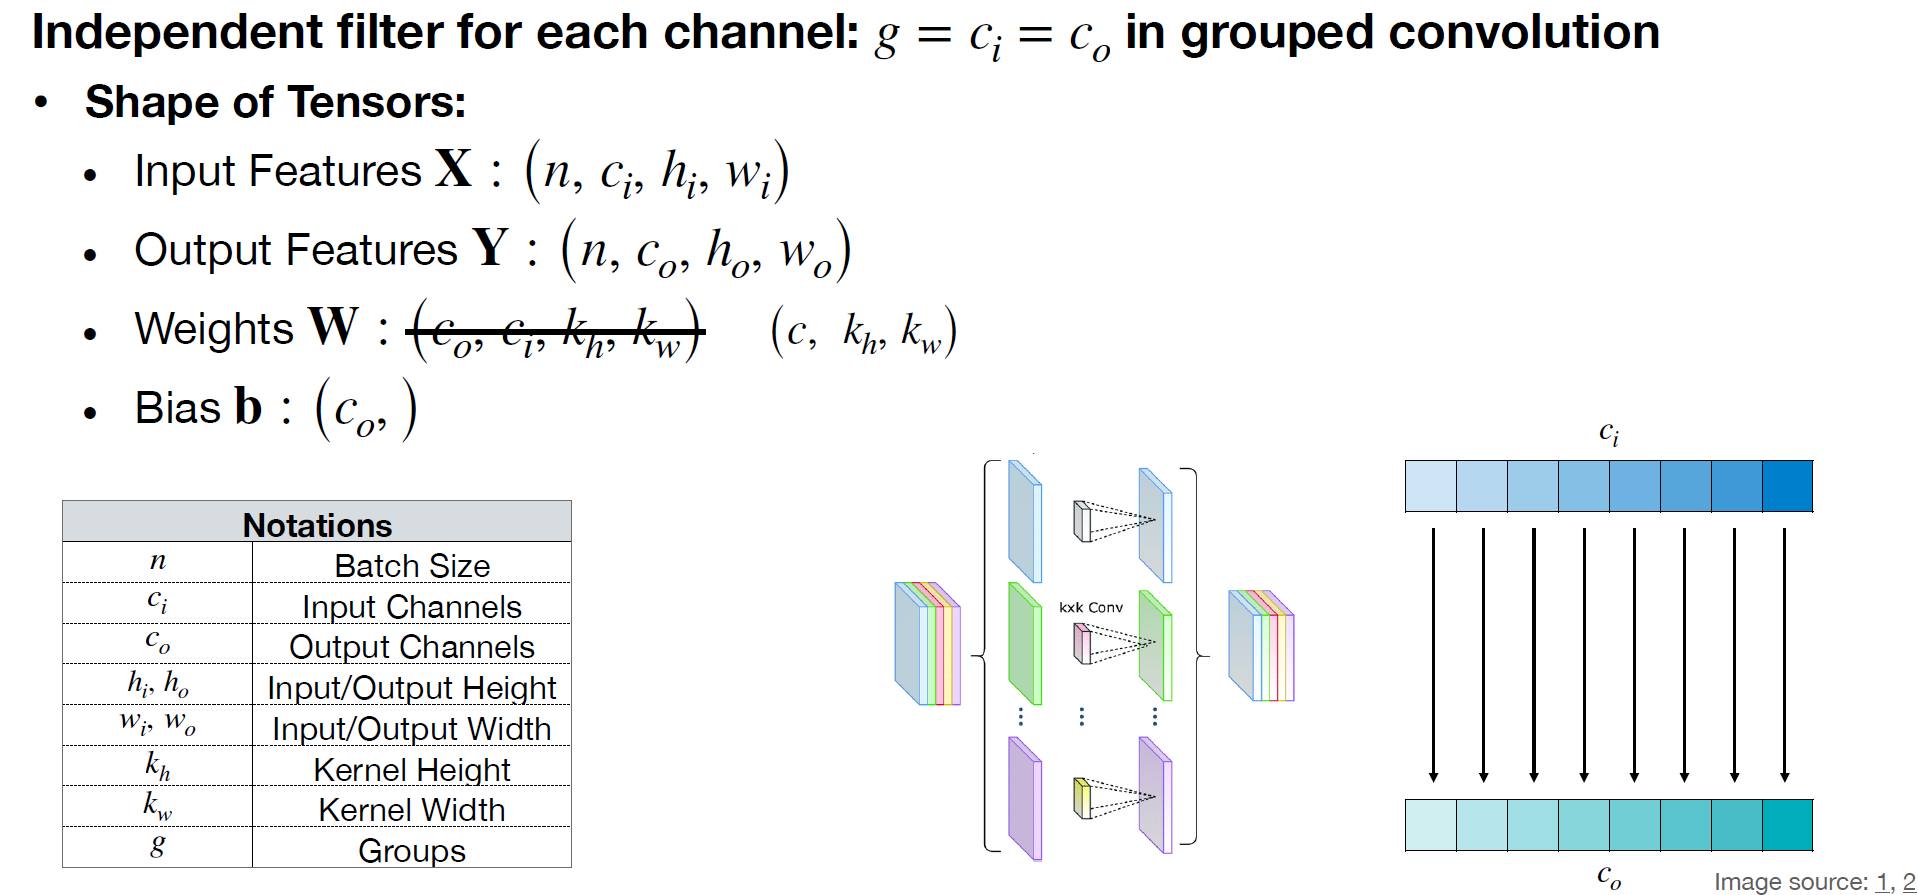

Image source:  https://hanlab.mit.edu/courses/2024-fall-65940


Depth-wise convolution is a special case of grouped convolution where:

$$
G = C
$$

Each input channel has its own filter.


For input channel $ c $:

$$
Y_c = W_c * X_c
$$

Where:
- $ W_c $ is a filter applied only to channel $ c $

No mixing of channels occurs.

**Parameter Count**

Standard convolution:

$$
K_h \times K_w \times C \times F
$$

Depth-wise convolution:

$$
K_h \times K_w \times C
$$

This significantly reduces parameters and computation.

**Depthwise Separable Convolution**

Often followed by pointwise convolution (1×1):

$$
Y = W_{1\times1} * (W_{depth} * X)
$$

This is used in MobileNet.

Overall, these different types of convolution exist because deep learning models must balance accuracy, speed, and computational efficiency. While 2D convolution is powerful for spatial learning in images, 1D convolution is essential for sequential data. Grouped convolution and depth-wise convolution are engineering innovations that help reduce computation and memory usage, making deep learning models more scalable and deployable. Understanding these variations helps students and practitioners not only build better models but also design systems suited for real-world applications such as mobile AI, healthcare monitoring, and autonomous systems.

In [ ]:
model_depthwise = models.Sequential([
    layers.Input(shape=(window_size, num_input_channels)),

    layers.SeparableConv1D(filters=8,
                           kernel_size=3,
                           strides=1,
                           padding="valid",
                           activation="relu"),

    layers.Flatten(),
    layers.Dense(num_activities, activation="softmax")
])

model_depthwise.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d_1              │ (None, 18, 8)          │            74 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509 (1.99 KB)

 Trainable params: 509 (1.99 KB)

 Non-trainable params: 0 (0.00 B)

## Given

- Input width: $ w_i = 20 $
- Input channels: $ c_i = 6 $
- Output channels: $ c_o = 8 $
- Kernel size: $ k_w = 3 $
- Stride = 1
- Padding = valid
- Dense output units = 3

---

## Step 1 — Output Width

$$
w_o = \left\lfloor \frac{w_i - k_w}{s} \right\rfloor + 1
$$

$$
w_o = \frac{20 - 3}{1} + 1 = 18
$$

Output shape:

$$
(18, 8)
$$

---

## Step 2 — Depthwise Convolution Parameters

Depthwise convolution applies one filter per input channel.

Weights:

$$
k_w \cdot c_i
$$

$$
= 3 \cdot 6 = 18
$$

Bias:

Not applied separately in Keras implementation.

Total depthwise parameters:

$$
18
$$

---

## Step 3 — Pointwise Convolution Parameters (1×1)

Pointwise convolution mixes channels and produces final outputs.

Weights:

$$
c_i \cdot c_o
$$

$$
= 6 \cdot 8 = 48
$$

Bias:

Applied once at final output stage:

$$
c_o = 8
$$

Total pointwise parameters:

$$
48 + 8 = 56
$$

---

## Step 4 — Total SeparableConv1D Parameters

$$
\text{Depthwise weights} + \text{Pointwise weights} + \text{Bias}
$$

$$
= 18 + 48 + 8
$$

$$
= 74
$$

This matches the model summary.

---

## Step 5 — Flatten Layer

Flatten output size:

$$
w_o \cdot c_o = 18 \cdot 8 = 144
$$

Trainable parameters:

$$
0
$$

---

## Step 6 — Dense Layer

Dense input units:

$$
144
$$

Dense output units:

$$
3
$$

Parameters:

$$
144 \cdot 3 + 3
$$

$$
= 432 + 3 = 435
$$

---

## Step 7 — Total Trainable Parameters

$$
\text{SeparableConv1D} + \text{Dense}
$$

$$
74 + 435
$$

$$
= 509
$$

#**Note:** There are questions given before or after of a code cell. You have to answer all question and show them to TAs before finishing the tutorial. Reflection question are not Mandatory.

### **Questions**

1. What is the main difference between 1D convolution and 2D convolution?
2. What is the key difference between grouped convolution and depth-wise convolution?
3. Why is depth-wise convolution more suitable for lightweight models?

**Answers**

1.

2.

## Import Libraries

In this section, we import the required libraries for building, training, and analyzing the CNN model. TensorFlow and Keras are used for constructing neural networks. NumPy is used for numerical operations, while Matplotlib and Seaborn help visualize results such as training curves and confusion matrices.

These tools form the foundation of the entire workflow.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import time


## Load Dataset


We now load the MNIST dataset, which contains images of handwritten digits from 0 to 9. Each image is 28×28 pixels and grayscale. This dataset is widely used for learning computer vision fundamentals because it is simple, clean, and fast to train on. We split the data into training and testing sets. The model will learn patterns from the training data and will be evaluated on the testing data.

This dataset is ideal for learning CNN fundamentals because:
- small size
- fast training
- clear visual patterns

#### **Think Before You Run**

1. What type of problem is this?
- classification / regression / clustering

2. What will be the shape of MNIST images?

3. Will images be grayscale or RGB?

**Note:** Write your answers before running the next cell.

**Answers**

1.

2.

3.

Raw image pixel values range from 0 to 255. Neural networks learn better when inputs are normalized, therefore, we scale values to the range 0–1.

We also add a channel dimension because CNNs expect image inputs in the format:
(height, width, channels).

Since MNIST images are grayscale, the channel dimension is 1.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train, x_test = x_train/255.0, x_test/255.0

# CNN expects channel dimension → add (28,28,1)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

class_labels = ["0","1","2","3","4","5","6","7","8","9"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

## **Observation Exercise**

1. How many training samples are there?
2. How many testing samples?
3. What is the input shape?
4. Why did we add a channel dimension?

**Answers**

1.

2.

3.

4.

### Visualize Sample Image

Before training a model, it is important to understand the data visually. This step helps verify whether images are loaded correctly and gives insight into the patterns the CNN will learn.

Observe the digit carefully and think about what visual features help distinguish it from other digits.

In [ ]:
idx = 6   # Change this value to see different samples
plt.imshow(x_train[idx])
plt.title(class_labels[y_train[idx]])
plt.axis('off')
plt.show()

## Build CNN Model

We now define the CNN architecture. Convolutional layers extract important spatial features from images, pooling layers reduce dimensionality and computational load, and dense layers perform classification.

This architecture gradually transforms raw pixel values into meaningful features that help identify digits.

### **Architecture Prediction**

Before running model.summary():
1. Which layer will have the highest parameters?
- Conv layers OR Dense layers?

Explain why.

**Answer**

In [ ]:
def cnn_model():
    model = models.Sequential([
        layers.Conv2D(16,(3,3),activation='relu',padding='same',input_shape=(28,28,1)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(32,(3,3),activation='relu',padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(64,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])
    return model

model = cnn_model()
model.summary()

The model summary provides detailed information about each layer, including output shapes and number of parameters. This helps us understand how complex the model is and how information flows through different layers.

Pay attention to which layers contribute the most parameters.

### **Model Analysis**

1. Which layer has the most parameters?
2. Why does Dense layer dominate parameters?
3. How does pooling help computational efficiency?

**Answer**

1.

2.

3.

### Compile Model

Compilation prepares the model for training by defining:
- optimizer: how weights are updated
- loss function: how prediction errors are measured
- evaluation metric: how performance is tracked

This step sets the learning strategy.

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model

The model now learns from the training data. During each epoch, the CNN adjusts its weights to minimize prediction error. Validation data is used to evaluate performance on unseen samples, helping detect overfitting. Observe how training accuracy and validation accuracy evolve.

A Convolutional Neural Network learns patterns in images using:

- Convolution layers → extract visual features
- Pooling layers → reduce spatial size
- Dense layers → perform classification

In [ ]:
cnn_history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

## Plot Learning Curves

Training and validation curves show how the model improves over time. Loss curves represent error reduction, while accuracy curves represent performance improvement.

These plots help identify:
- overfitting
- underfitting
- convergence

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

# Accuracy
plt.subplot(1,2,2)
plt.plot(cnn_history.history['accuracy'], label='Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")

plt.show()

### **Curve Interpretation**

1. Is model overfitting?
2. Is model underfitting?
3. At which epoch did learning stabilize?
4. If validation loss increases — what does it mean?

**Answers**

1.

2.

3.

4.

## Metrics

### Performance Metrics

After training, we evaluate how well the model predicts digits using accuracy, confusion matrix, and classification report.

Accuracy shows overall performance, while the confusion matrix reveals which digits the model confuses with each other. The classification report provides precision, recall, and F1-score for each class.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### **Error Analysis**

Look at confusion matrix.
1. Which digits are confused most?

Explain visually.

In [ ]:
print(classification_report(y_test, y_pred_classes))

## Understanding CNN Parameters

Every trainable layer has parameters.

### Convolution Layer Parameters

Formula:
Parameters = (Kernel Height × Kernel Width × Input Channels × Filters) + Bias

### Dense Layer Parameters

Parameters = (Input Units × Output Units) + Bias

### Pooling Layer

No parameters — only reduces size.

Understanding parameters helps us estimate:
- model complexity
- memory usage
- training cost


### Parameter Metrics

Parameters include weights and biases that the model learns during training. A higher number of parameters increases model complexity but also increases computational cost and risk of overfitting.

This section helps understand how different layers contribute to model size.

In [ ]:
num_params = model.count_params()
print("Total Parameters:", num_params)

### Layer-wise Parameters

In [ ]:
for layer in model.layers:
    params = layer.count_params()
    print(f"{layer.name}: {params} params")

### Memory Size

Memory usage depends on the number of parameters and data type used to store them. Estimating model size is important for deploying models on resource-constrained devices.

Includes:
- parameters
- model size
- activations

In [ ]:
model_size = num_params * np.float32().nbytes
print("Model Size (MB):", model_size/(1024**2))

### Activation Metrics

Activations are intermediate outputs generated by each layer. They influence memory consumption during training and inference. Measuring total and peak activations helps understand runtime resource requirements.

In [ ]:
total_activations = 0
peak_activations = 0

for layer in model.layers:
    if hasattr(layer, 'output_shape'):
        activations = np.prod(layer.output_shape[1:])
        total_activations += activations
        peak_activations = max(peak_activations, activations)

print("Total Activations:", total_activations)
print("Peak Activations:", peak_activations)

## Weight Distribution (Before/After Training)

Weights represent learned knowledge in the network. Visualizing weight distributions helps understand how the model evolves during training and whether learning is stable.

**Learning Insight**

1. Compare:
- initial weights vs trained weights
2. Questions:
- Are weights centered?
- Are they sparse?
- Why normalization helps?

**Answers**

In [ ]:
def normalize_weights(weights):
    return (weights - np.mean(weights)) / (np.std(weights)+1e-8)

layer_weights = {}

for layer in model.layers:
    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
        weights = layer.get_weights()[0]
        layer_weights[layer.name] = normalize_weights(weights.flatten())

plt.figure(figsize=(12,8))
for i,(name,w) in enumerate(layer_weights.items()):
    plt.subplot(len(layer_weights)//2+1,2,i+1)
    sns.histplot(w,bins=50)
    plt.title(name)

plt.show()

### Save & Load Model

Saving model weights allows reuse without retraining. Loading them ensures reproducibility and is essential for real-world deployment.

In [ ]:
model.save_weights("cnn_weights.weights.h5")

model_loaded = cnn_model()
model_loaded.load_weights("cnn_weights.weights.h5")

## FLOPs & MACs Calculation

FLOPs and MACs measure how much computation the model requires. These metrics are critical for evaluating model efficiency, especially when deploying on mobile or edge devices. Understanding computational cost helps design faster and lighter models.

MACs → Multiply-Accumulate operations  
FLOPs → Floating point operations  
OPS → Operations per second

These determine how fast a model runs.

**Computational Thinking**

1. Which layer contributes most FLOPs?
- Conv
- Dense
- Pooling

Why?

**Answer**

In [ ]:
def calculate_metrics(model):
    total_flops = 0
    total_MACs = 0

    for layer in model.layers:

        if isinstance(layer, tf.keras.layers.Conv2D):
            input_shape = layer.input.shape
            output_shape = layer.output.shape

            kernel_ops = np.prod(layer.kernel_size) * input_shape[-1]
            output_elements = np.prod(output_shape[1:])
            flops = kernel_ops * output_elements

        elif isinstance(layer, tf.keras.layers.Dense):
            input_units = layer.input.shape[-1]
            output_units = layer.output.shape[-1]
            flops = input_units * output_units

        else:
            flops = 0

        MACs = flops/2
        total_flops += flops
        total_MACs += MACs

        print(layer.name,"FLOPs:",flops,"MACs:",MACs)

    print("\nTotal FLOPs:",total_flops)
    print("Total MACs:",total_MACs)

calculate_metrics(model)

## Manual Architecture Exercise Section

This section encourages manual thinking. Students analyze the architecture and estimate parameters, memory, and operations without relying on automated tools. This builds deeper understanding of model design.

In [ ]:
# Architecture reference

# Input: 28x28x1
# Conv1: 16 filters
# Conv2: 32 filters
# FC: 64 neurons
# Output: 10 classes

## Model Comparison Table

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Parameters", "Model Size (MB)", "Total FLOPs"],
    "Value": ["", num_params, model_size/(1024**2), ""]
})

results

## Final Task

summarize observations such as accuracy, parameter count, model size, and computational cost. This helps compare performance and efficiency together.

Fill the results table:

| Metric | Value |
|---|---|
| Accuracy | |
| Total Parameters | |
| Model Size (MB) | |
| FLOPs | |
| MACs | |
| Peak Activations | |

## Analyzing Parameters of Popular CNN Architectures

In this section, we will analyze three important CNN architectures:

- AlexNet
- VGG16
- MobileNet

These models represent different design philosophies in deep learning.

AlexNet:
One of the earliest deep CNN models that showed the power of deep learning for image classification.

VGG16:
A deeper and more structured CNN with uniform architecture.

MobileNet:
A lightweight model designed for mobile and embedded devices using depth-wise separable convolutions.

Instead of training these models, we will load them and analyze:

- Number of parameters
- Model size
- Layer-wise parameter distribution
- Efficiency differences

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG16, MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

## Define AlexNet

In [ ]:
def alexnet_model():
    model = Sequential([
        Conv2D(96, (11,11), strides=4, activation='relu', padding='same', input_shape=(224,224,3)),
        MaxPooling2D(3,3),

        Conv2D(256, (5,5), activation='relu', padding='same'),
        MaxPooling2D(3,3),

        Conv2D(384, (3,3), activation='relu', padding='same'),
        Conv2D(384, (3,3), activation='relu', padding='same'),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(4096, activation='relu'),
        Dense(4096, activation='relu'),
        Dense(1000, activation='softmax')
    ])
    return model

In [ ]:
alexnet = alexnet_model()
alexnet.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,066,792 (129.95 MB)

 Trainable params: 34,066,792 (129.95 MB)

 Non-trainable params: 0 (0.00 B)

### Load VGG16

In [ ]:
vgg16 = VGG16(weights=None, input_shape=(224,224,3))
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

### Load MobileNet

In [ ]:
mobilenet = MobileNet(weights=None, input_shape=(224,224,3))
mobilenet.summary()

Model: "mobilenet_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 4,253,864 (16.23 MB)

 Trainable params: 4,231,976 (16.14 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
def analyze_model_parameters(model, name):

    total_params = model.count_params()
    model_size = total_params * np.float32().nbytes

    print(f"\n{name} Analysis")
    print("-"*40)
    print("Total Parameters:", total_params)
    print("Model Size (MB):", model_size/(1024**2))

    layerwise = []

    for layer in model.layers:
        params = layer.count_params()
        if params > 0:
            layerwise.append((layer.name, params))

    return pd.DataFrame(layerwise, columns=["Layer", "Parameters"])

In [ ]:
alex_df = analyze_model_parameters(alexnet, "AlexNet")
vgg_df = analyze_model_parameters(vgg16, "VGG16")
mobile_df = analyze_model_parameters(mobilenet, "MobileNet")


AlexNet Analysis
----------------------------------------
Total Parameters: 34066792
Model Size (MB): 129.95449829101562

VGG16 Analysis
----------------------------------------
Total Parameters: 138357544
Model Size (MB): 527.7921447753906

MobileNet Analysis
----------------------------------------
Total Parameters: 4253864
Model Size (MB): 16.227203369140625


## Compare Models

In [ ]:
comparison = pd.DataFrame({
    "Model": ["AlexNet", "VGG16", "MobileNet"],
    "Parameters": [
        alexnet.count_params(),
        vgg16.count_params(),
        mobilenet.count_params()
    ]
})

comparison["Model Size (MB)"] = comparison["Parameters"] * np.float32().nbytes / (1024**2)

comparison

,Model,Parameters,Model Size (MB)
0,AlexNet,34066792,129.954498
1,VGG16,138357544,527.792145
2,MobileNet,4253864,16.227203


## Visual Comparison

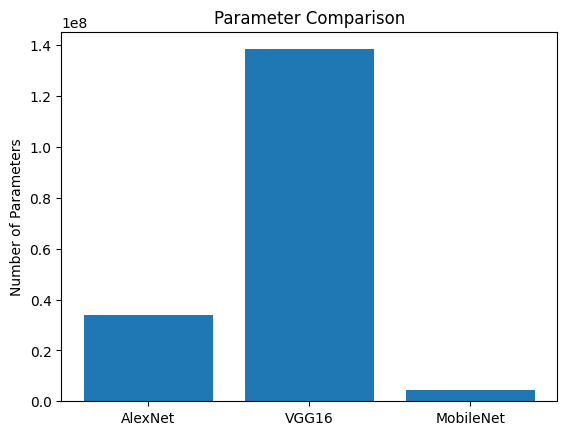

In [ ]:
import matplotlib.pyplot as plt

plt.bar(comparison["Model"], comparison["Parameters"])
plt.title("Parameter Comparison")
plt.ylabel("Number of Parameters")
plt.show()

## Reflection Questions

In real-world AI systems, selecting a model involves balancing accuracy, speed, memory, and computational cost. This tutorial demonstrates that evaluating a neural network requires more than measuring prediction accuracy.

Understanding these trade-offs prepares you to build practical, deployable machine learning systems.

Reflect on:

1. Why accuracy alone is not sufficient?
2. Which layer contributes most parameters?
3. Which layer is computationally expensive?
4. How to reduce model size?
5. How to deploy this on mobile?
6. Which model has the highest parameters?
7. Why is VGG16 computationally expensive?
8. Why does MobileNet have fewer parameters?
9. What role does depth-wise convolution play in MobileNet?
10. Which model is best suited for mobile devices?
11. Which model is best suited for high accuracy tasks?
12. Why does standard convolution have the highest computation cost?
13. Which convolution type is best for real-time applications and why?
14. Which convolution type is most suitable for sensor-based activity recognition?
15. Which convolution type is most suitable for image classification and why?

----------------------------------------------------------------THE END---------------------------------------------------------------